In [1]:
import pandas as pd
import re
import os
import paramiko
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from pprint import pprint
from itertools import chain
from sqlalchemy import create_engine
ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy()) 
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
data = pd.read_csv(r'C:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\data.csv')

C:\Users\glj523\AppData\Local\Temp\ipykernel_6212\1027675796.py:1: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r'C:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\data.csv')


In [3]:
line_counts_nsx = pd.read_csv(r"c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\line_counts.tsv", sep='\t')
line_counts_nsx['File'] = line_counts_nsx['File'].apply(lambda x: x.split('/')[-1])
line_counts_nsx['ID'] = line_counts_nsx['File'].apply(lambda x: x.split('_')[0])
line_counts_nsx = line_counts_nsx[line_counts_nsx['ID'] != 'Undetermined']
line_counts_nsx['eDNA Concentration'] = line_counts_nsx['File'].apply(lambda x: x.split('_')[1])
line_counts_nsx['Read ID'] = line_counts_nsx['File'].apply(lambda x: x.split('_')[2])
line_counts_nsx['Lane'] = line_counts_nsx['File'].apply(lambda x: x.split('_')[3])
line_counts_nsx['Read Type'] = line_counts_nsx['File'].apply(lambda x: x.split('_')[4])
line_counts_nsx['library_id'] = line_counts_nsx['ID'].apply(lambda x: x.split('-')[0])
line_counts_nsx = line_counts_nsx.rename(columns={'LineCount': "fastqc_raw__Total Sequences"})
line_counts_nsx['Platform'] = 'NovaSeqX'
line_counts_nsx['Protocol'] = 'Double'
line_counts_nsx = line_counts_nsx[~((line_counts_nsx['ID'].str.contains('Control')) | (line_counts_nsx['ID'].str.contains('ExrNTC')))]
line_counts_nsx = line_counts_nsx.drop(columns=['File', 'ID', 'Read ID'])
line_counts_nsx = line_counts_nsx.reindex(columns=list(data.columns))

data = data[~((data['Lane'] == 'L005') 
     & (data['Read Type'].isin(['R1', 'R2'])) 
     & (data['Protocol'] == 'Double')
     & (data['Platform'] == 'NovaSeqX'))]

data = pd.concat([data, line_counts_nsx])

assert (data[((data['Lane'] == 'L005') 
     & (data['Read Type'].isin(['R1', 'R2'])) 
     & (data['Protocol'] == 'Double')
     & (data['Platform'] == 'NovaSeqX'))]["fastqc_raw__Total Sequences"] == line_counts_nsx["fastqc_raw__Total Sequences"]).all()

In [4]:
data_ns6 = data[data["Platform"] == "NovaSeq6"]
data_nsX = data[data["Platform"] == "NovaSeqX"]

In [5]:
sum_cols = ["fastqc_raw__Total Sequences", "fastqc_trimmed__Total Sequences"]
box_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"] 

In [6]:
print(data_ns6[data_ns6["fastqc_trimmed__Total Sequences"] > 0]["qc_type"].unique())
print(data_ns6[data_ns6["fastqc_raw__Total Sequences"] > 0]["qc_type"].unique())

['L001_collapsed' 'L001_R1' 'L001_R2' 'L001_singleton' 'L002_collapsed'
 'L002_R1' 'L002_R2' 'L002_singleton' 'L003_collapsed' 'L003_R1' 'L003_R2'
 'L003_singleton' 'L004_collapsed' 'L004_R1' 'L004_R2' 'L004_singleton']
['L001_R1' 'L001_R2' 'L002_R1' 'L002_R2' 'L003_R1' 'L003_R2' 'L004_R1'
 'L004_R2']


In [7]:
print(data_nsX[data_nsX["fastqc_trimmed__Total Sequences"] > 0]["qc_type"].unique())
print(data_nsX[data_nsX["fastqc_raw__Total Sequences"] > 0]["qc_type"].unique())

['L001_R1' 'L001_R2' 'L001_collapsed' 'L001_singleton' 'L006_R1' 'L006_R2'
 'L006_collapsed' 'L006_singleton' 'L005_collapsed' 'L005_singleton'
 'L008_R1' 'L008_R2' 'L008_collapsed' 'L008_singleton' 'L005_R1' 'L005_R2']
['L001_R1' 'L001_R2' 'L006_R1' 'L006_R2' 'L008_R1' 'L008_R2' 'L005_R1'
 'L005_R2' nan]


Percentage of reads aligned out of total number of collapsed reads

In [8]:
print(data_ns6[data_ns6['Read Type'] == 'collapsed']['reads_aligned'].sum() / data_ns6[data_ns6['Read Type'] == 'collapsed']['fastqc_trimmed__Total Sequences'].sum() * 100)
print(data_nsX[data_nsX['Read Type'] == 'collapsed']['reads_aligned'].sum() / data_nsX[data_nsX['Read Type'] == 'collapsed']['fastqc_trimmed__Total Sequences'].sum() * 100)

4.425306329872793
5.2012201777849905


Same as above but per lane, single

Text(0.5, 1.0, 'NovaSeqX')

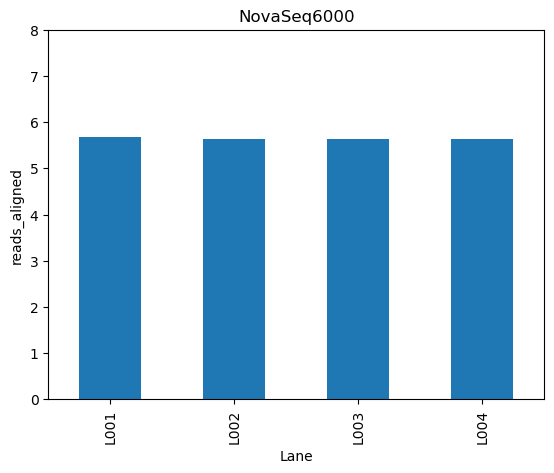

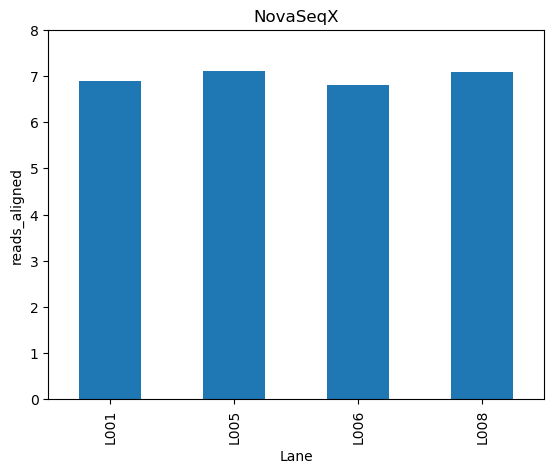

In [9]:
protocol = 'Double'

g1 = \
    (data_ns6[
        (data_ns6['Read Type'] == 'collapsed') 
        & (data_ns6['Protocol'] == protocol)][
            ['Lane', 'reads_aligned']]
     .groupby('Lane')
     .sum()
     .reset_index()
     .sort_values('Lane')
     .reset_index(drop=True))
divider = (data_ns6[
    (data_ns6['Read Type'] == 'collapsed') 
    & (data_ns6['Protocol'] == protocol)][
        ['Lane', 'fastqc_trimmed__Total Sequences']
        ]
 .groupby('Lane')
 .sum()
 .reset_index()
 .sort_values('Lane')
 .reset_index(drop=True)
 )
g1['reads_aligned'] = g1['reads_aligned'] / divider['fastqc_trimmed__Total Sequences'] * 100
g2 = \
    (data_nsX[
        (data_nsX['Read Type'] == 'collapsed') 
        & (data_nsX['Protocol'] == protocol)][
            ['Lane', 'reads_aligned']]
     .groupby('Lane')
     .sum()
     .reset_index()
     .sort_values('Lane')
     .reset_index(drop=True))
divider = (data_nsX[
    (data_nsX['Read Type'] == 'collapsed') 
    & (data_nsX['Protocol'] == protocol)][
        ['Lane', 'fastqc_trimmed__Total Sequences']
        ]
 .groupby('Lane')
 .sum()
 .reset_index()
 .sort_values('Lane')
 .reset_index(drop=True)
 )
g2['reads_aligned'] = g2['reads_aligned'] / divider['fastqc_trimmed__Total Sequences'] * 100
g1.plot(kind='bar', x='Lane', ylabel='reads_aligned', ylim=(0,8), legend=False).set_title('NovaSeq6000')
g2.plot(kind='bar', x='Lane', ylabel='reads_aligned', ylim=(0,8), legend=False).set_title('NovaSeqX')

Scatter plot of total raw reads per library

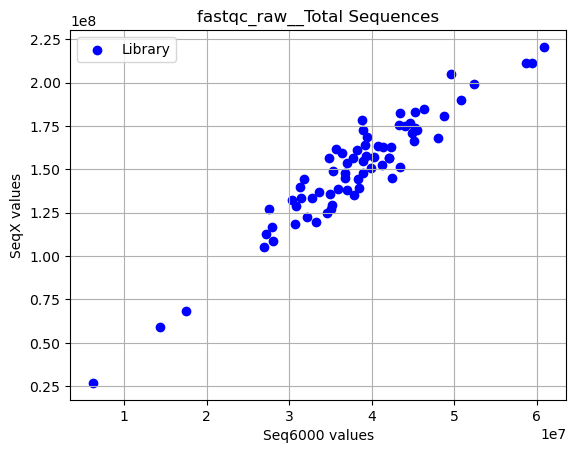

In [10]:
def scatter_plot(full_dataset, protocol, value_column):
    if protocol == "Single":
        filter = full_dataset["Protocol"] == "Single"
    
    elif protocol == "Double":
        filter = full_dataset["Protocol"] == "Double"
    
    elif protocol == "Both":
        filter = (full_dataset["Protocol"] == "Single") | (full_dataset["Protocol"] == "Double")
        
    else:
        raise Exception()
    
    full_dataset = full_dataset[filter]
    data_nsX = full_dataset[(full_dataset["Platform"] == "NovaSeqX") & (full_dataset["Read Type"] == "R1") & (full_dataset["Lane"] == "L005")]
    data_ns6 = full_dataset[(full_dataset["Platform"] == "NovaSeq6") & (full_dataset["Read Type"] == "R1") & (full_dataset["Lane"] == "L004")]
    
    x = data_nsX[["library_id", value_column]].groupby("library_id").sum().reset_index().sort_values("library_id")[value_column]
    y = data_ns6[["library_id", value_column]].groupby("library_id").sum().reset_index().sort_values("library_id")[value_column]

    # Create scatter plot
    plt.scatter(y, x, color='blue', label='Library', marker='o')
    
    # Customize the plot
    plt.title(value_column)  # Add a title
    plt.xlabel("Seq6000 values")  # Label for x-axis
    plt.ylabel("SeqX values")  # Label for y-axis
    plt.legend()  # Show legend
    plt.grid(True)  # Add gridlines
    plt.show()  # Display the plot
scatter_plot(data, "Double", "fastqc_raw__Total Sequences")

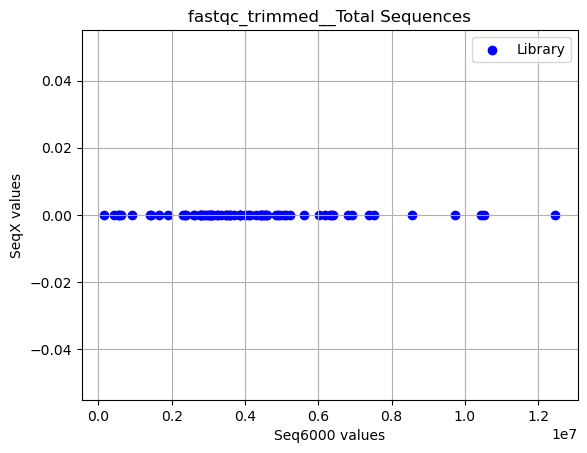

In [11]:
scatter_plot(data, "Double", "fastqc_trimmed__Total Sequences")

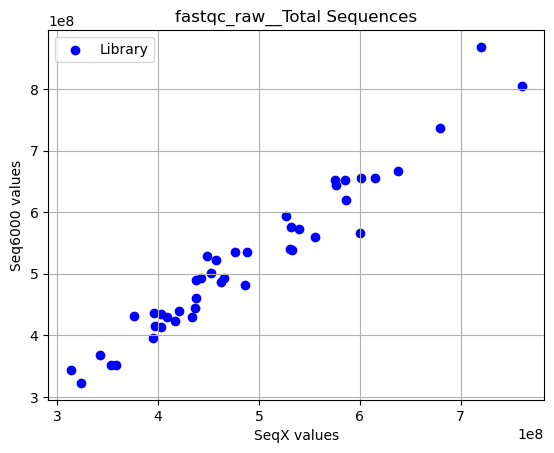

In [12]:
def scatter_plot(value):
    x = data_nsX[data_nsX["Protocol"] == "Single"][["library_id", value]].groupby("library_id").sum().reset_index().sort_values("library_id")[value]
    y = data_ns6[data_ns6["Protocol"] == "Single"][["library_id", value]].groupby("library_id").sum().reset_index().sort_values("library_id")[value]

    # Create scatter plot
    plt.scatter(x, y, color='blue', label='Library', marker='o')

    # Customize the plot
    plt.title("fastqc_raw__Total Sequences")  # Add a title
    plt.xlabel("SeqX values")  # Label for x-axis
    plt.ylabel("Seq6000 values")  # Label for y-axis
    plt.legend()  # Show legend
    plt.grid(True)  # Add gridlines
    plt.show()  # Display the plot
scatter_plot("fastqc_raw__Total Sequences")

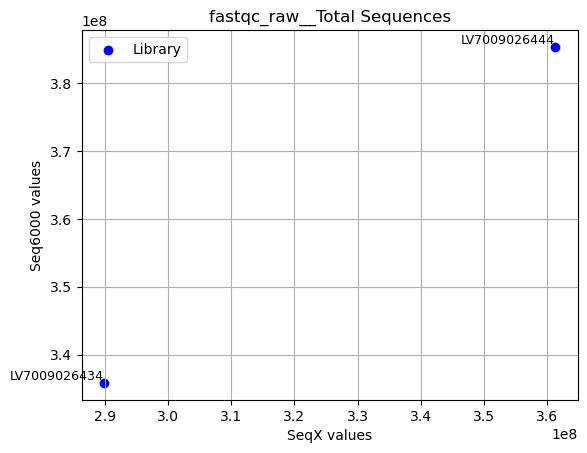

In [13]:
weird = ["LV7009026444", "LV7009026434"]

# Example data
x = data_nsX[data_nsX["library_id"].isin(weird)][["library_id", "fastqc_raw__Total Sequences"]].groupby("library_id").sum().reset_index().sort_values("library_id")["fastqc_raw__Total Sequences"]
y = data_ns6[data_ns6["library_id"].isin(weird)][["library_id", "fastqc_raw__Total Sequences"]].groupby("library_id").sum().reset_index().sort_values("library_id")["fastqc_raw__Total Sequences"]
labels = data_nsX[data_nsX["library_id"].isin(weird)][["library_id", "fastqc_raw__Total Sequences"]].groupby("library_id").sum().reset_index().sort_values("library_id")["library_id"]

# Create scatter plot
plt.scatter(x, y, color='blue', label='Library', marker='o')

# Add labels to each point
for i, label in enumerate(labels):
    plt.text(x[i], y[i], label, fontsize=9, ha='right', va='bottom')  # Adjust alignment as needed

# Customize the plot
plt.title("fastqc_raw__Total Sequences")  # Add a title
plt.xlabel("SeqX values")  # Label for x-axis
plt.ylabel("Seq6000 values")  # Label for y-axis
plt.legend()  # Show legend
plt.grid(True)  # Add gridlines
plt.show()  # Display the plot

Compare raw output between lanes on NovaSeqX:

In [33]:
# Data for Single Protocol
group_single = data_ns6[data_ns6["Protocol"] == "Double"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset_single = group_single[group_single["fastqc_raw__Total Sequences"] > 0].reset_index()

# Data for Double Protocol
group_double = data_nsX[data_nsX["Protocol"] == "Double"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset_double = group_double[group_double["fastqc_raw__Total Sequences"] > 0].reset_index()

# Create a subplot figure with 1 row and 2 columns
fig = make_subplots(rows=1, cols=2, shared_yaxes=True, subplot_titles=["NS6", "NSX"])

# Add bar chart for Single Protocol
fig.add_trace(
    go.Bar(
        x=group_reset_single["Lane"],
        y=group_reset_single["fastqc_raw__Total Sequences"],
        name="NS6000"
    ),
    row=1, col=1
)

# Add bar chart for Double Protocol
fig.add_trace(
    go.Bar(
        x=group_reset_double["Lane"],
        y=group_reset_double["fastqc_raw__Total Sequences"],
        name="NSX"
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    height=600, width=1200,
    yaxis_title="Total Sequences",
    yaxis_range=[0, 3e10],
    showlegend=False
)

# Show the plot
fig.show()

<Axes: title={'center': 'NovaSeqX Double'}, xlabel='Lane'>

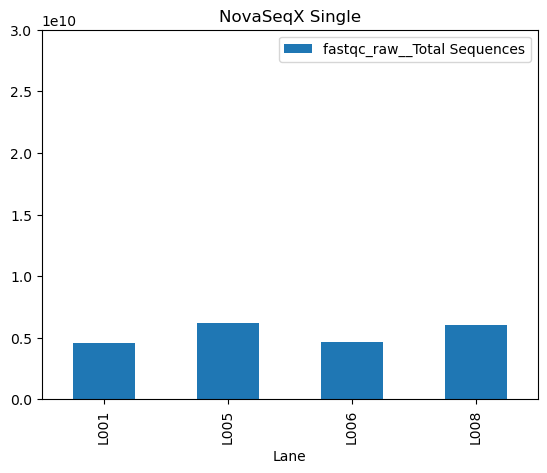

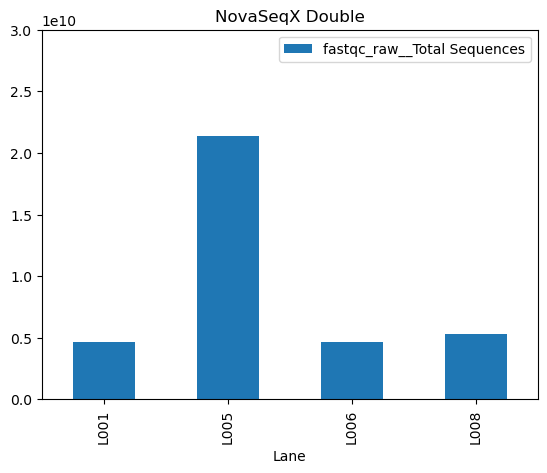

In [15]:
group = data_nsX[data_nsX["Protocol"] == "Single"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeqX Single", ylim=(0, 3e10))

group = data_nsX[data_nsX["Protocol"] == "Double"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeqX Double", ylim=(0, 3e10))

Compare raw output between lanes on NovaSeq6:

<Axes: title={'center': 'NovaSeq6 Double'}, xlabel='Lane'>

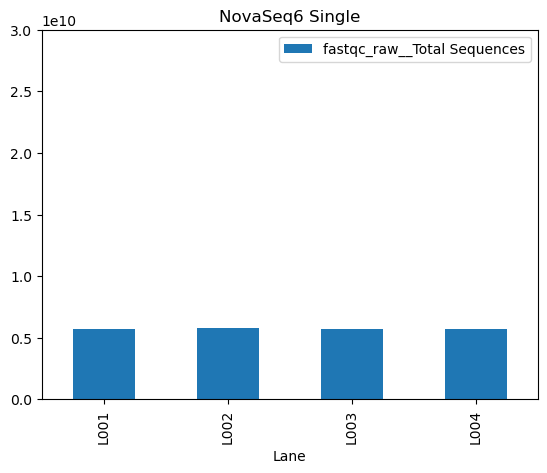

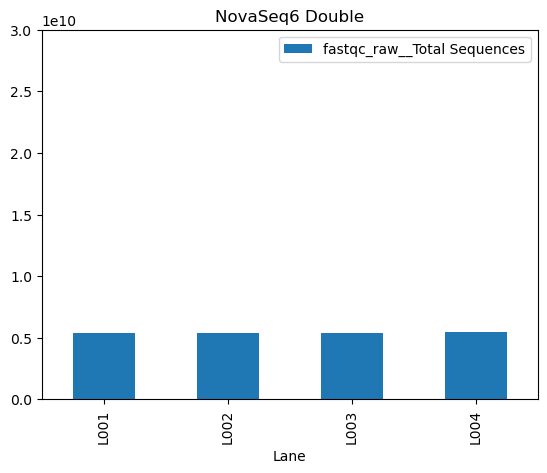

In [16]:
group = data_ns6[data_ns6["Protocol"] == "Single"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeq6 Single", ylim=(0, 3e10))

group = data_ns6[data_ns6["Protocol"] == "Double"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeq6 Double", ylim=(0, 3e10))

Num of raw reads comparison single stranded

In [17]:
print("NovaSeqX: \t", data[(data["Platform"] == "NovaSeqX") & (data["Protocol"] == "Single")]["fastqc_raw__Total Sequences"].sum() / 1000000000)
print("NovaSeq6000: \t", data[(data["Platform"] == "NovaSeq6") & (data["Protocol"] == "Single")]["fastqc_raw__Total Sequences"].sum() / 1000000000)

NovaSeqX: 	 21.39200169
NovaSeq6000: 	 22.857635646


Num of raw reads comparison double stranded

In [18]:
print("NovaSeqX: \t", data[(data["Platform"] == "NovaSeqX") & (data["Protocol"] == "Double")]["fastqc_raw__Total Sequences"].sum() / 1000000000)
print("NovaSeq6000: \t", data[(data["Platform"] == "NovaSeq6") & (data["Protocol"] == "Double")]["fastqc_raw__Total Sequences"].sum() / 1000000000)

NovaSeqX: 	 36.038008056
NovaSeq6000: 	 21.631185972


Verify that all libraries have been sequenced on all lanes:

In [19]:
for id in data["library_id"].unique():
    if len(data[(data["Platform"] == "NovaSeq6") & (~data["fastqc_raw__Total Sequences"].isna()) & (data["library_id"] == id)]["Lane"].unique()) != 4:
        print("Error")
        
for id in data["library_id"].unique():
    if len(data[(data["Platform"] == "NovaSeqX") & (~data["fastqc_raw__Total Sequences"].isna()) & (data["library_id"] == id)]["Lane"].unique()) != 4:
        print("Error")

Percentage of collapsed out of total on NS6

In [20]:
data_ns6[data_ns6["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_ns6["fastqc_raw__Total Sequences"].sum() * 100

35.38328073771909

Percentage of collapsed out of total on NSX

In [21]:
data_nsX[data_nsX["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_nsX["fastqc_raw__Total Sequences"].sum() * 100

26.04721961072258

Percentage of discarded reads during fastp out of total reads

In [22]:
def get_total_after_fastp(platform):
    total_trimmed = 0
    for index, row in data[data["Platform"] == platform].iterrows():
        if row["Read Type"] == "collapsed":
            total_trimmed = total_trimmed + (row["fastqc_trimmed__Total Sequences"] * 2)
        else:
            pass
    
    return total_trimmed

def get_fastp_discarded(platform):
        before_fastp = data[data["Platform"] == platform]["fastqc_raw__Total Sequences"].sum()
        after = get_total_after_fastp(platform)
        diff = before_fastp - after

        return (diff / before_fastp) * 100
    
print("NovaSeqX: \t", get_fastp_discarded("NovaSeqX"))
print("NovaSeq6000: \t", get_fastp_discarded("NovaSeq6"))

NovaSeqX: 	 47.90556077855484
NovaSeq6000: 	 29.233438524561823


Output from fastp single stranded novaseqx

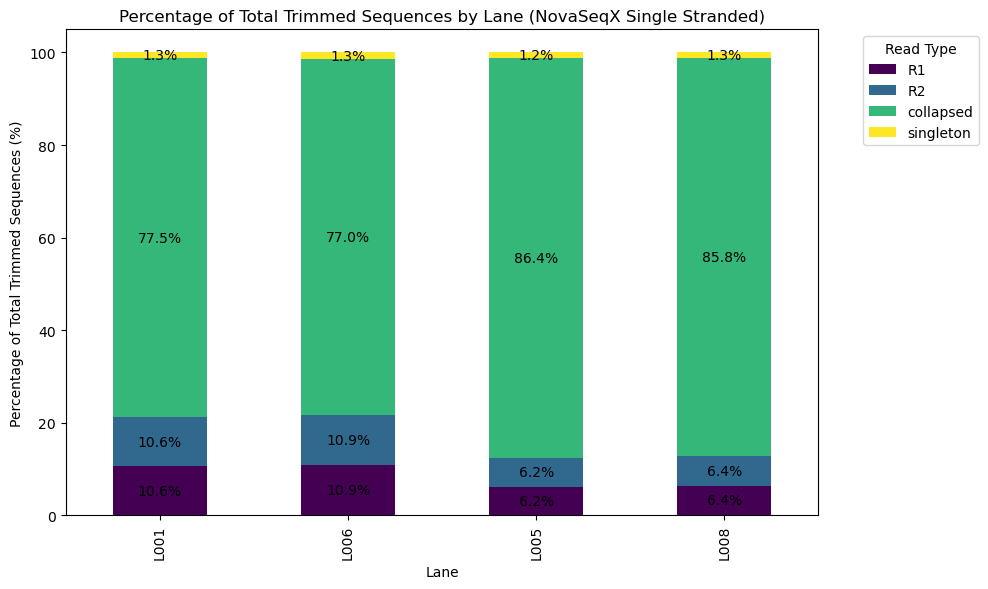

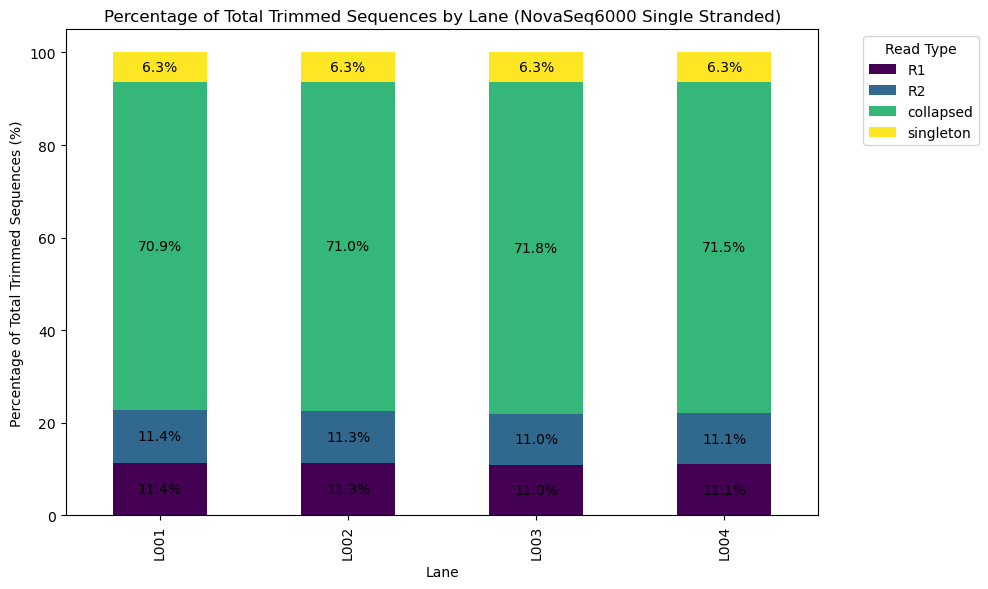

In [23]:
group = data_nsX[data_nsX["Protocol"] == "Single"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences"]].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")["fastqc_trimmed__Total Sequences"].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L006", "L005", "L008"]]

# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeqX Single Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


group = data_ns6[data_ns6["Protocol"] == "Single"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences"]].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")["fastqc_trimmed__Total Sequences"].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L002", "L003", "L004"]]

# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeq6000 Single Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Output from fastp Double stranded

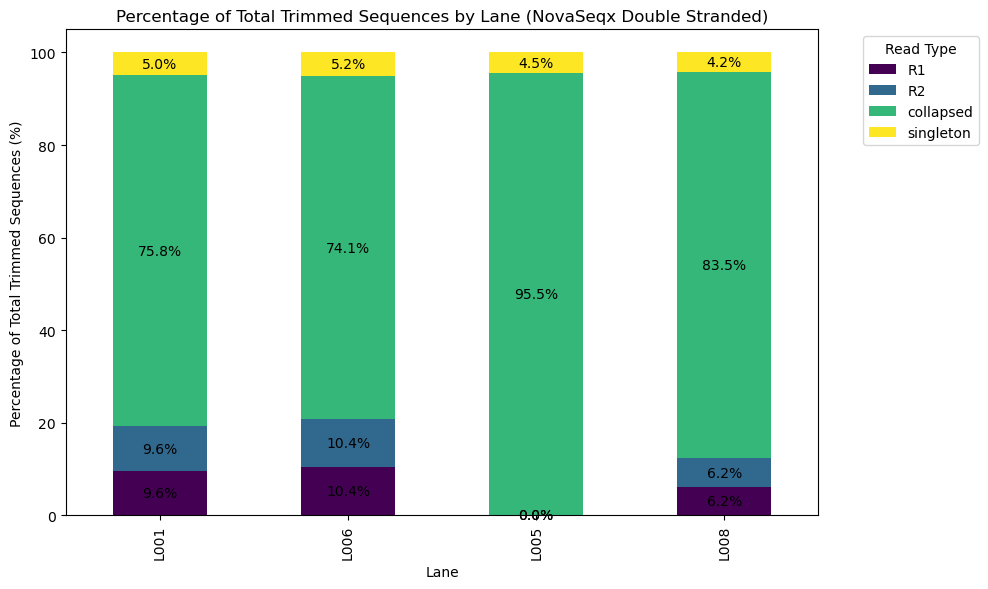

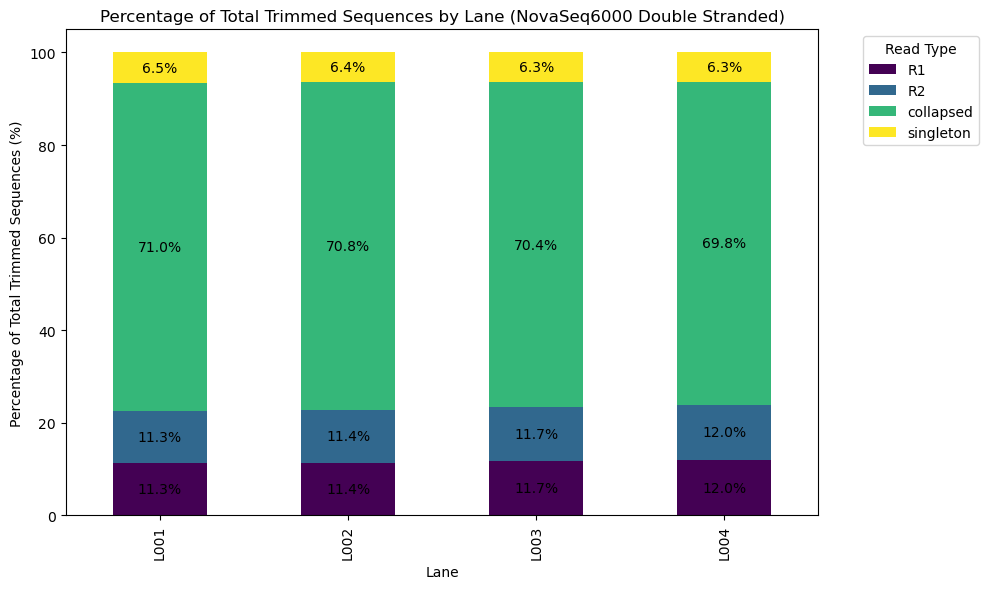

In [24]:
group = data_nsX[data_nsX["Protocol"] == "Double"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences"]].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")["fastqc_trimmed__Total Sequences"].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L006", "L005", "L008"]]

# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeqx Double Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


group = data_ns6[data_ns6["Protocol"] == "Double"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences"]].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")["fastqc_trimmed__Total Sequences"].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L002", "L003", "L004"]]

# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeq6000 Double Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Median sequence length NS6

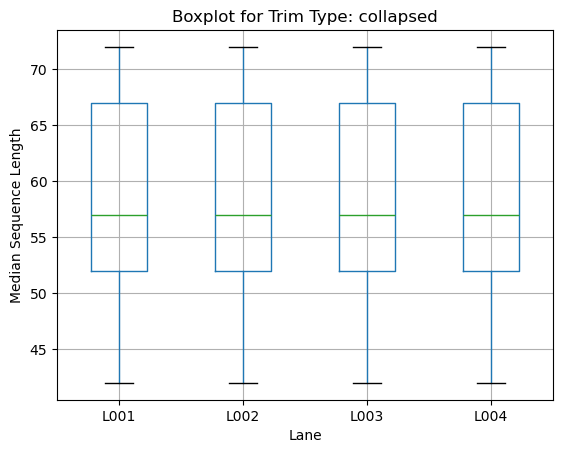

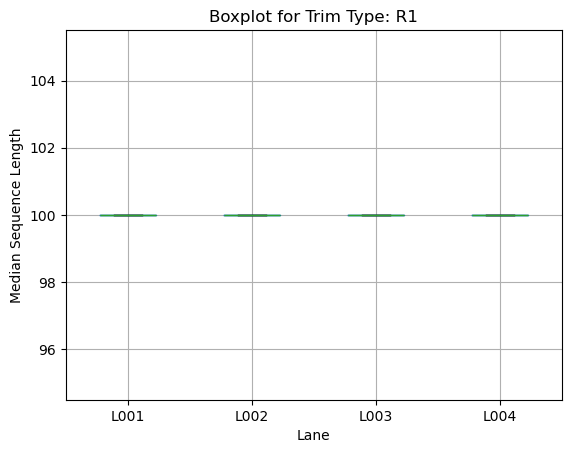

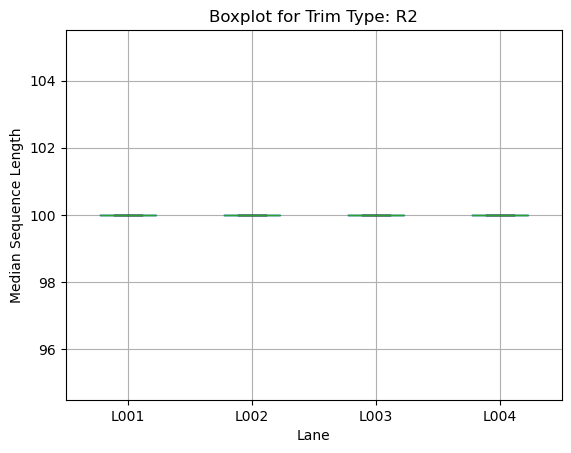

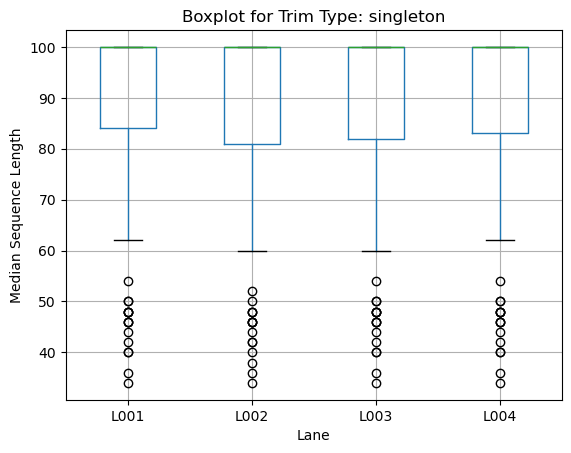

In [25]:
for read_type in data_ns6[(~data_ns6["fastqc_trimmed__median_sequence_length"].isna())]["Read Type"].unique():
    plt.figure()
    data_ns6[(~data_ns6["fastqc_trimmed__median_sequence_length"].isna()) & (data_ns6["Read Type"] == read_type)][["Lane", "fastqc_trimmed__median_sequence_length"]].pivot(columns="Lane", values="fastqc_trimmed__median_sequence_length").boxplot(column=["L001", "L002", "L003", "L004"])
    plt.title(f"Boxplot for Trim Type: {read_type}")  # Add a title for clarity
    plt.ylabel("Median Sequence Length")
    plt.xlabel("Lane")
    plt.show()

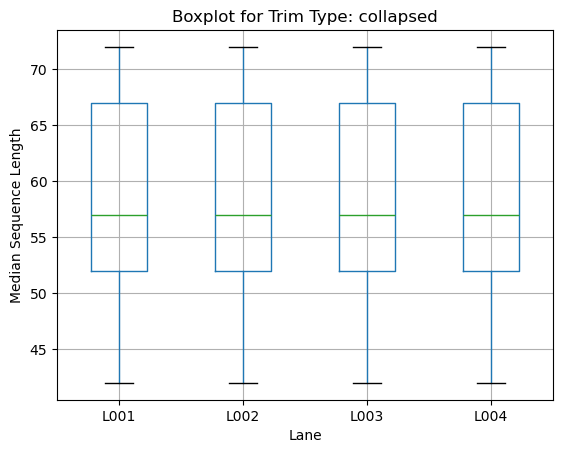

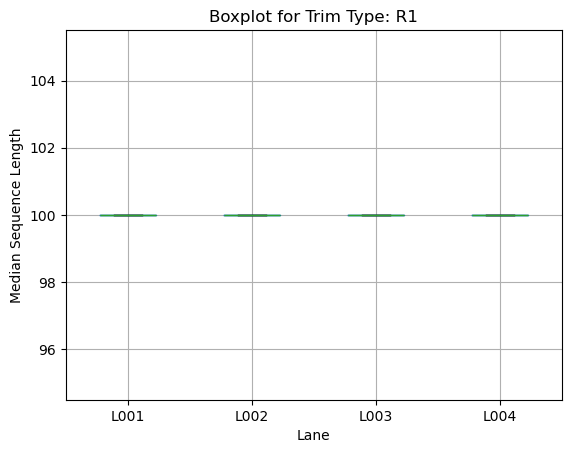

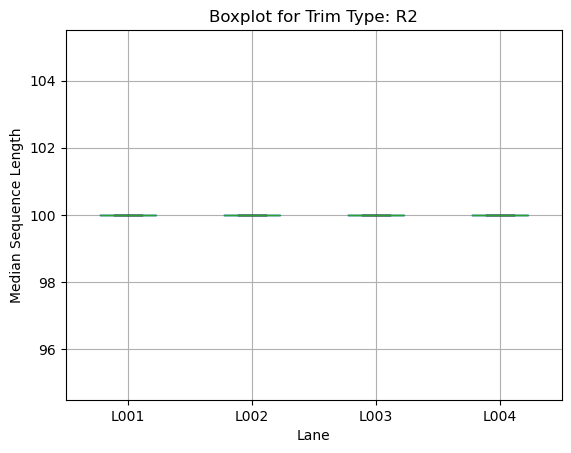

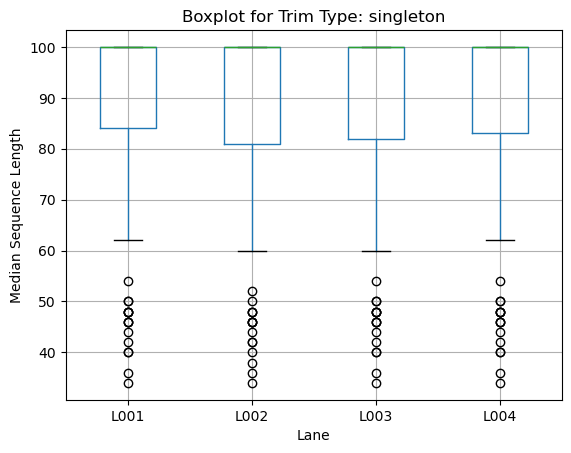

In [26]:
for read_type in data_ns6[(~data_ns6["fastqc_trimmed__median_sequence_length"].isna())]["Read Type"].unique():
    plt.figure()
    data_ns6[(~data_ns6["fastqc_trimmed__median_sequence_length"].isna()) & (data_ns6["Read Type"] == read_type)][["Lane", "fastqc_trimmed__median_sequence_length"]].pivot(columns="Lane", values="fastqc_trimmed__median_sequence_length").boxplot(column=["L001", "L002", "L003", "L004"])
    plt.title(f"Boxplot for Trim Type: {read_type}")  # Add a title for clarity
    plt.ylabel("Median Sequence Length")
    plt.xlabel("Lane")
    plt.show()

Median sequence length NSX

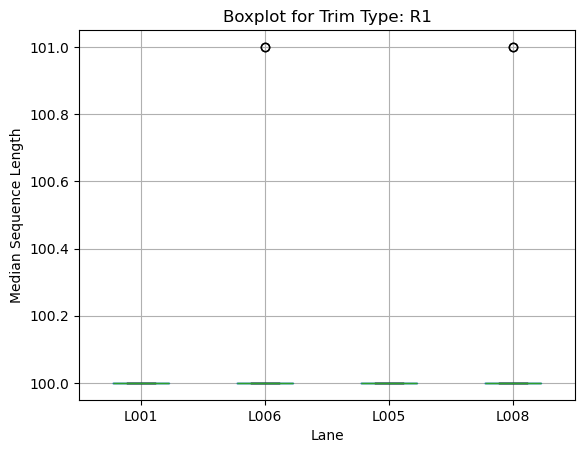

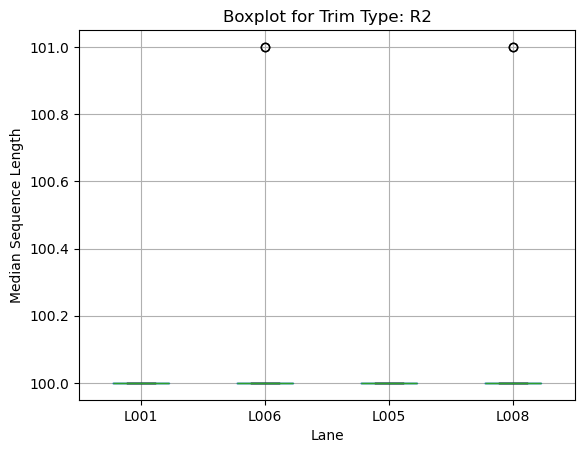

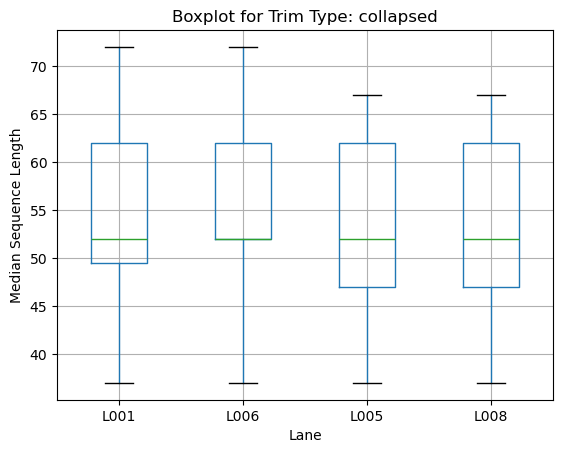

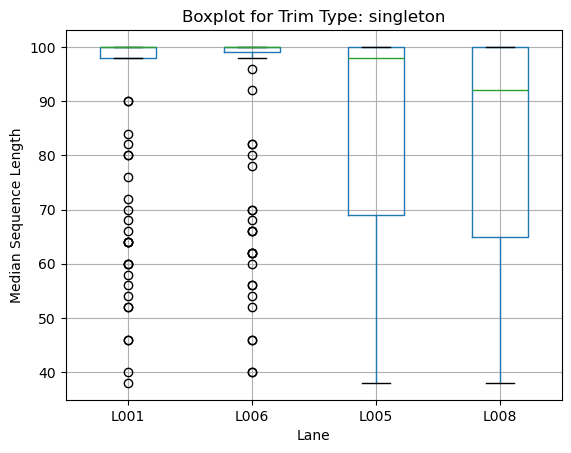

In [27]:
for read_type in data_nsX[(~data_nsX["fastqc_trimmed__median_sequence_length"].isna()) & (data_nsX['Protocol'] == 'Single')]["Read Type"].unique():
    plt.figure()
    data_nsX[(~data_nsX["fastqc_trimmed__median_sequence_length"].isna()) & (data_nsX["Read Type"] == read_type)][["Lane", "fastqc_trimmed__median_sequence_length"]].pivot(columns="Lane", values="fastqc_trimmed__median_sequence_length").boxplot(column=["L001", "L006", "L005", "L008"])
    plt.title(f"Boxplot for Trim Type: {read_type}")  # Add a title for clarity
    plt.ylabel("Median Sequence Length")
    plt.xlabel("Lane")
    plt.show()

<Axes: xlabel='eDNA Concentration'>

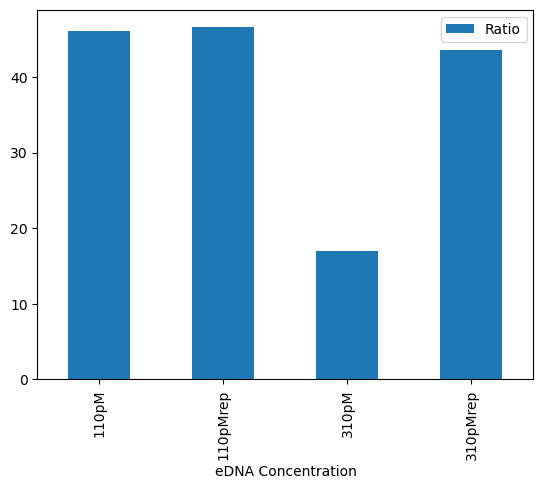

In [28]:
trimmed_sum_per_lane = data_nsX[data_nsX["fastqc_trimmed__Total Sequences"] > 0 ][["eDNA Concentration", "fastqc_trimmed__Total Sequences"]].groupby("eDNA Concentration").sum().reset_index()
raw_sum_per_lane = data_nsX[data_nsX["fastqc_raw__Total Sequences"] > 0 ][["eDNA Concentration", "fastqc_raw__Total Sequences"]].groupby("eDNA Concentration").sum().reset_index()
merge = raw_sum_per_lane.merge(trimmed_sum_per_lane) 
merge["Ratio"] = (merge["fastqc_trimmed__Total Sequences"] / merge["fastqc_raw__Total Sequences"]) * 100
merge[["eDNA Concentration", "Ratio"]].plot(kind="bar", x="eDNA Concentration")

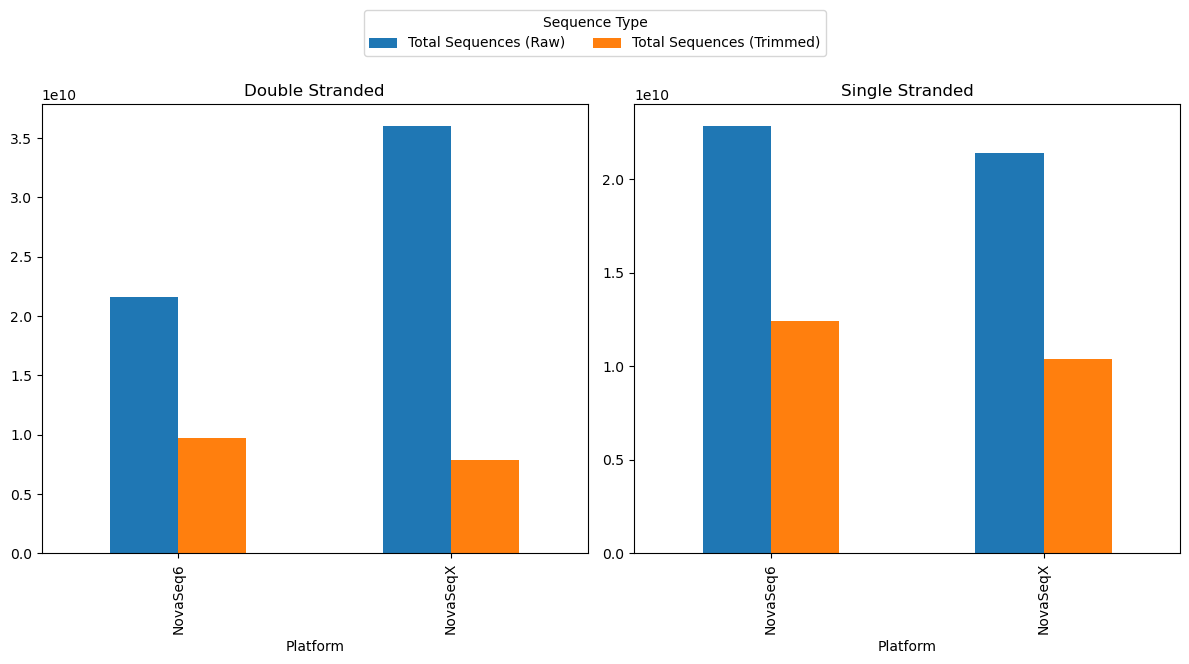

In [29]:
def make_sum_plot_1(column1, column2, combined_df):
    combined_df[column1] = combined_df[column1].astype(float)
    combined_df[column2] = combined_df[column2].astype(float)

    double_df = combined_df[combined_df['Protocol'] == 'Double']
    single_df = combined_df[combined_df['Protocol'] == 'Single']
    # Calculate mean values for each platform and each sequencing type
    raw_sum_double = double_df.groupby('Platform')[column1].sum()

    trimmed_sum_double = double_df.groupby('Platform')[column2].sum()

    raw_sum_single = single_df.groupby('Platform')[column1].sum()

    trimmed_sum_single = single_df.groupby('Platform')[column2].sum()

    # Combine data into a DataFrame for easier plotting
    combined_sums_double = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_double,
        'Total Sequences (Trimmed)': trimmed_sum_double
    })

    # Combine data into a DataFrame for easier plotting
    combined_sums_single = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_single,
        'Total Sequences (Trimmed)': trimmed_sum_single
    })

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    combined_sums_double.plot(kind='bar', ax=ax[0], title="Double Stranded", legend=False)
    combined_sums_single.plot(kind='bar', ax=ax[1], title="Single Stranded", legend=False)

    handles, labels = ax[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Sequence Type")

    plt.tight_layout()
    plt.show()
make_sum_plot_1('fastqc_raw__Total Sequences', 'fastqc_trimmed__Total Sequences', data)

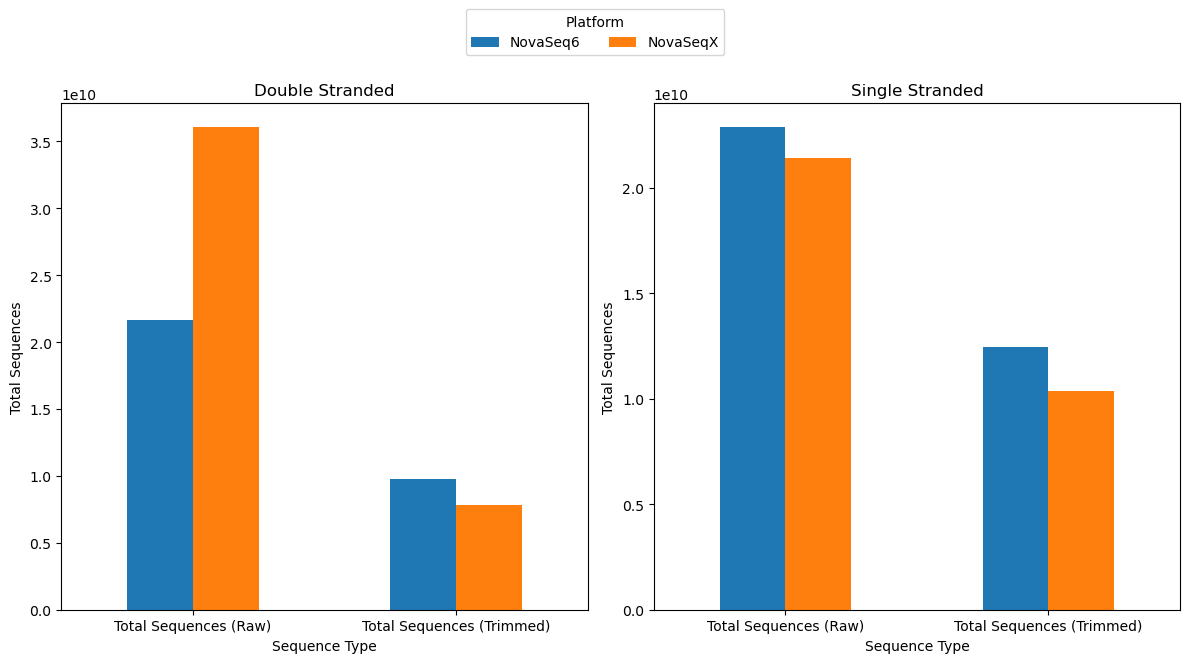

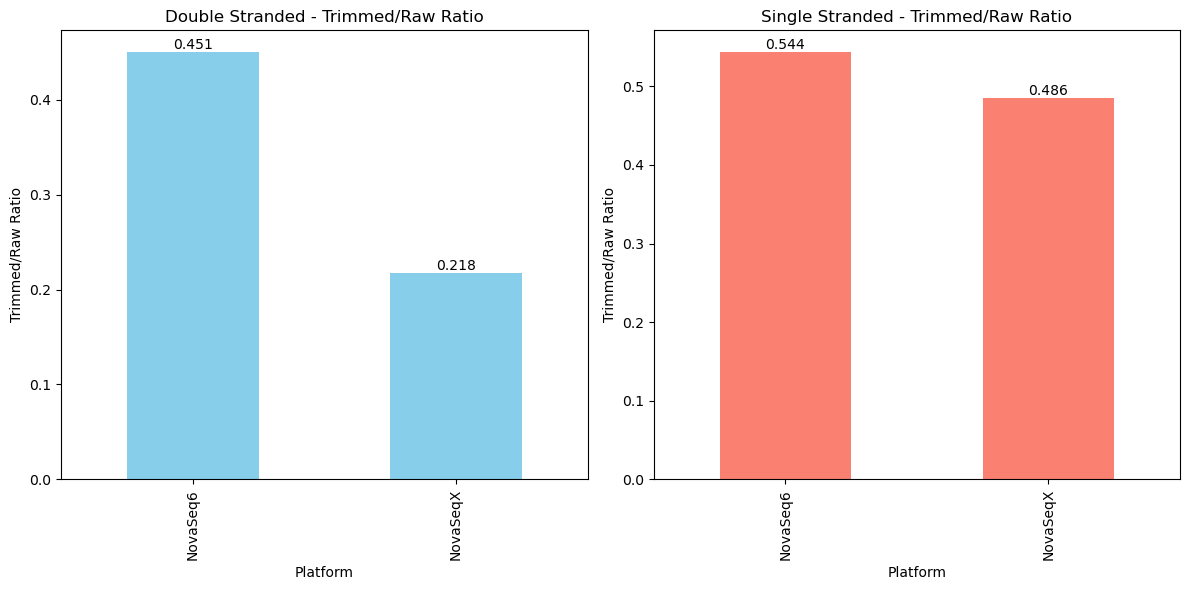

In [30]:
def plot2(double_data, single_data):
    double_df = double_data
    single_df = single_data
    # Calculate mean values for each platform and each sequencing type
    raw_sum_double = double_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
    trimmed_sum_double = double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

    raw_sum_single = single_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
    trimmed_sum_single = single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

    # Combine data into a DataFrame for easier plotting
    combined_sums_double = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_double,
        'Total Sequences (Trimmed)': trimmed_sum_double
    }).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

    combined_sums_single = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_single,
        'Total Sequences (Trimmed)': trimmed_sum_single
    }).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot for Double Stranded
    combined_sums_double.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[0], rot=0, legend=False)
    ax[0].set_title("Double Stranded")
    ax[0].set_ylabel("Total Sequences")

    # Plot for Single Stranded
    combined_sums_single.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[1], rot=0, legend=False)
    ax[1].set_title("Single Stranded")
    ax[1].set_ylabel("Total Sequences")

    # Adding legend
    handles, labels = ax[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Platform")

    plt.tight_layout()
    plt.show()

    
    # Calculate the ratio of trimmed to raw sequences
    ratio_double = (trimmed_sum_double / raw_sum_double).reset_index(name='Trimmed/Raw Ratio')
    ratio_single = (trimmed_sum_single / raw_sum_single).reset_index(name='Trimmed/Raw Ratio')

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot for Double Stranded ratios
    ratio_double.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[0], color='skyblue', legend=False)
    ax[0].set_title("Double Stranded - Trimmed/Raw Ratio")
    ax[0].set_ylabel("Trimmed/Raw Ratio")
    ax[0].set_xlabel("Platform")

    # Annotate the bars with the ratio values
    for i, value in enumerate(ratio_double['Trimmed/Raw Ratio']):
        ax[0].text(i, value, f"{value:.3f}", ha='center', va='bottom')

    # Plot for Single Stranded ratios
    ratio_single.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[1], color='salmon', legend=False)
    ax[1].set_title("Single Stranded - Trimmed/Raw Ratio")
    ax[1].set_ylabel("Trimmed/Raw Ratio")
    ax[1].set_xlabel("Platform")

    # Annotate the bars with the ratio values
    for i, value in enumerate(ratio_single['Trimmed/Raw Ratio']):
        ax[1].text(i, value, f"{value:.3f}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
plot2(data[data["Protocol"] == "Double"], data[data["Protocol"] == "Single"])

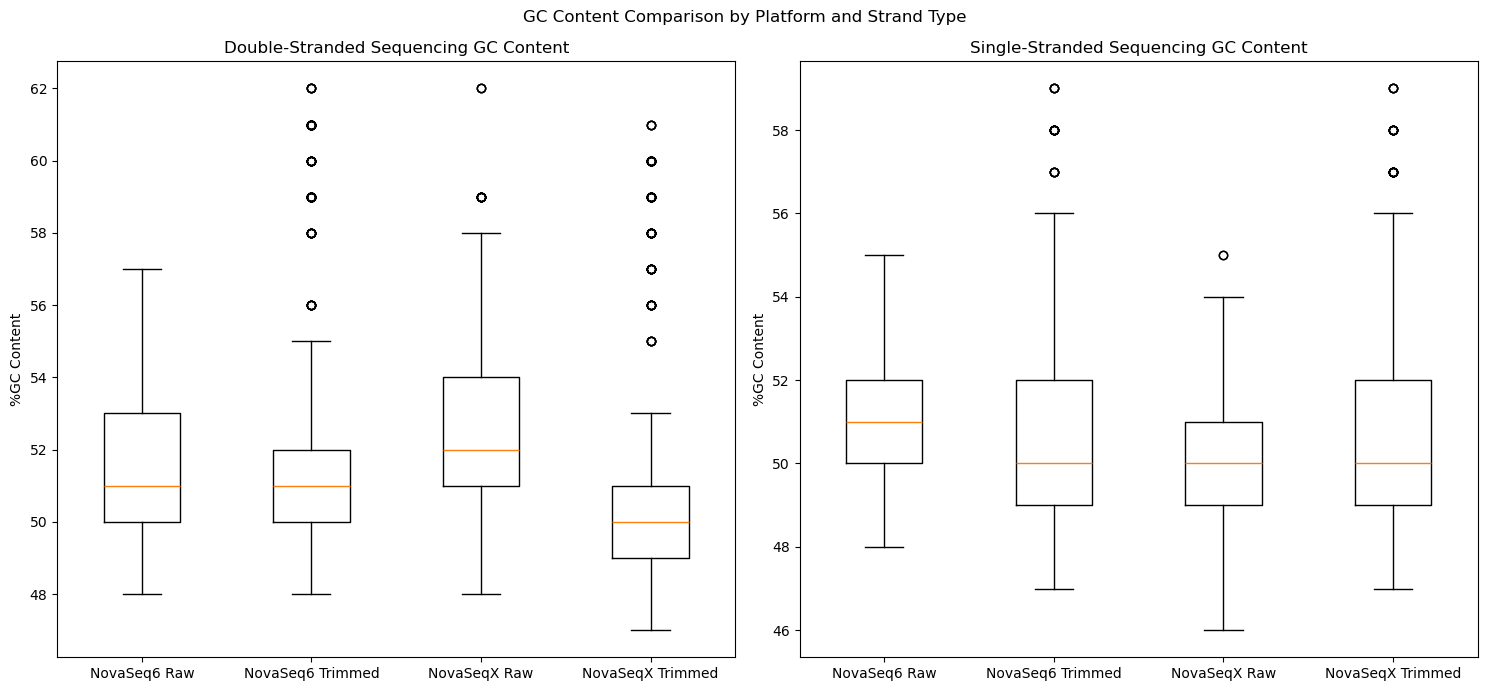

In [31]:
def make_boxplots(data, data_types, platforms, title, ax):
    gc_data = []
    labels = []

    for platform in platforms:
        for data_type in data_types:
            gc_content = data[data['Platform'] == platform][data_type].dropna()
            gc_data.append(gc_content)
            labels.append(f'{platform} {"Raw" if "raw" in data_type else "Trimmed"}')
    
    ax.boxplot(gc_data, tick_labels=labels)
    ax.set_title(title)
    ax.set_ylabel('%GC Content')

# Set up the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Platforms
platforms = data["Platform"].unique()

describe_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"]

# Plot GC content for double-stranded and single-stranded sequencing
make_boxplots(data[data["Protocol"] == "Double"], describe_cols, platforms, 'Double-Stranded Sequencing GC Content', axs[0])
make_boxplots(data[data["Protocol"] == "Single"], describe_cols, platforms, 'Single-Stranded Sequencing GC Content', axs[1])

# Display the plot
plt.suptitle('GC Content Comparison by Platform and Strand Type')
plt.tight_layout()
plt.show()